## Demostration of the skipgram 

##### Setup and Load Data

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from evaluate import nearest_neighbors, analogy

# Load pre-trained — no preprocessing needed
W = np.load('word2vec_embeddings.npy')

with open('vocab.pkl', 'rb') as f:
    data = pickle.load(f)
    vocab    = data['vocab']
    idx2word = data['idx2word']
    counts   = data['counts']

print(f"Embedding matrix: {W.shape}")
print(f"Vocab size: {len(vocab):,}")


Embedding matrix: (71290, 100)
Vocab size: 71,290


##### Training Summary

In [ ]:
# Load your pre-trained embeddings

W = np.load("word2vec_embeddings.npy")
print(f"Embedding matrix shape: {W.shape}") 
print(f"Embedding matrix shape: {W.shape}")  
print("Sample vectors:")
for i in range(3):
    word = idx2word[i]
    print(f"{word:<12} {W[i][:5]}...")


Embedding matrix shape: (71290, 100)
Embedding matrix shape: (71290, 100)
Sample vectors:
anarchism    [-0.45110148  0.39782315  0.38306528  0.83980142 -0.19385399]...
originated   [-0.2392365   0.2459238   0.11927987  0.19444834 -0.12865335]...
as           [0.25182057 0.05834501 0.28336275 0.01023714 0.24493214]...


##### Nearest Neighbors

In [4]:
print("=== NEAREST NEIGHBORS ===")
nearest_neighbors("king", vocab, idx2word, W, top_k=10)
nearest_neighbors("computer", vocab, idx2word, W, top_k=10)
nearest_neighbors("tennis", vocab, idx2word, W, top_k=10)


=== NEAREST NEIGHBORS ===
  aedh            0.7621
  lulach          0.7418
  plantagenet     0.7375
  chilperic       0.7366
  pretender       0.7328
  anshan          0.7288
  ducas           0.7285
  melisende       0.7256
  soter           0.7256
  gonatas         0.7207
  computers       0.8112
  hardware        0.7628
  computing       0.7620
  bootstrap       0.7588
  microcomputer   0.7584
  initialization  0.7438
  microcontroller 0.7435
  stibitz         0.7411
  asic            0.7404
  edvac           0.7402
  kournikova      0.8114
  partnering      0.7976
  safin           0.7840
  mcenroe         0.7806
  connors         0.7756
  wilander        0.7724
  hardenne        0.7716
  lleyton         0.7701
  bhupathi        0.7655
  slam            0.7615


##### Word Analogies

In [5]:
print("=== WORD ANALOGIES (king - man + woman = ?) ===")
print(analogy("man", "king", "woman", vocab, idx2word, W))
print(analogy("he", "king", "she", vocab, idx2word, W))
print(analogy("germany", "berlin", "france", vocab, idx2word, W))
print(analogy("small", "smaller", "large", vocab, idx2word, W))


=== WORD ANALOGIES (king - man + woman = ?) ===
aedh
aedh
paris
larger


#####  t-SNE Visualization

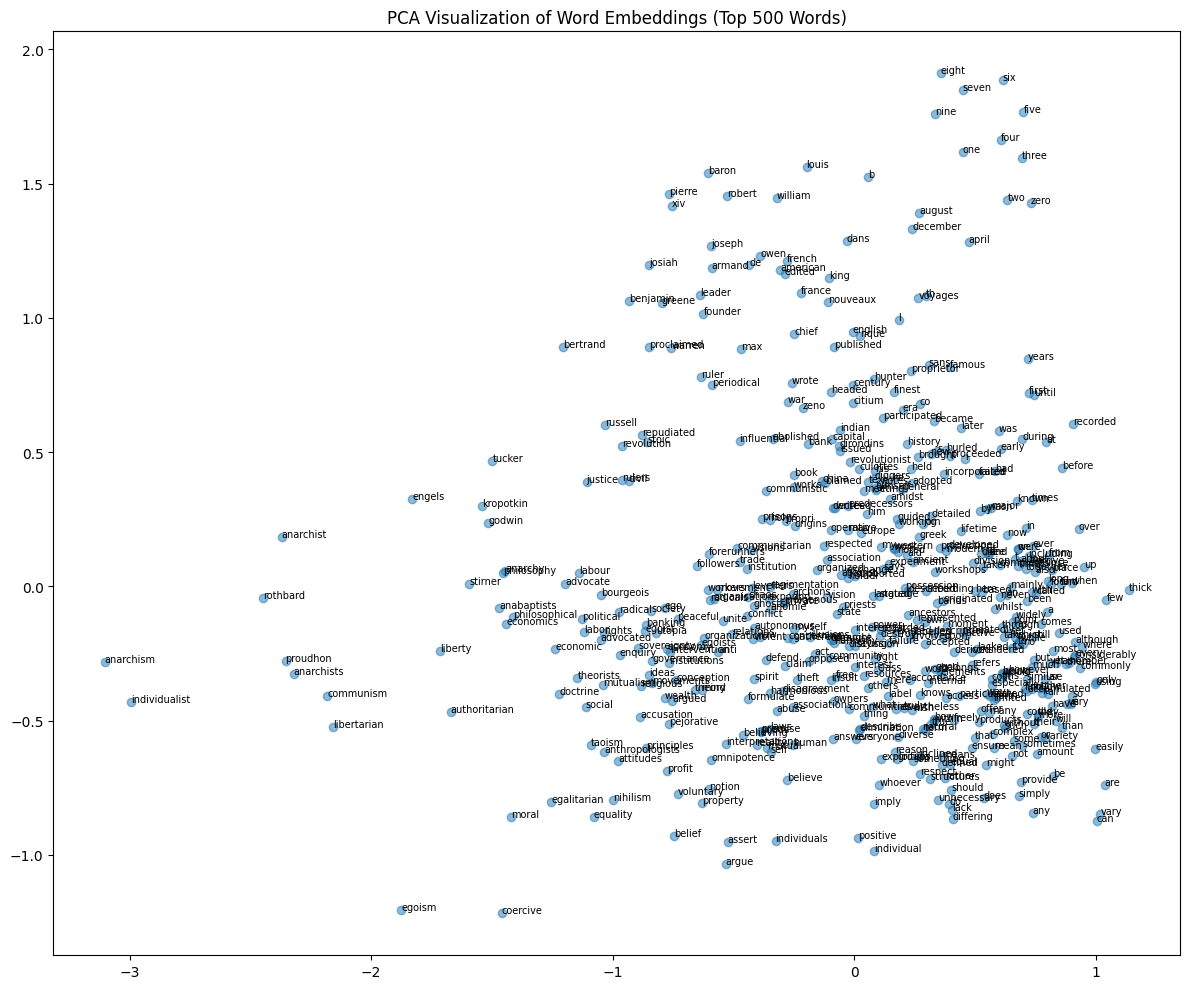

In [6]:
def pca_2d(W, n_words=500):
    """Pure NumPy PCA — no sklearn needed."""
    X = W[:n_words]
    X = X - X.mean(axis=0)           # center
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    return X @ Vt[:2].T              # project onto top 2 components

emb_2d = pca_2d(W, n_words=500)

plt.figure(figsize=(12, 10))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.5)
for i in range(500):
    plt.annotate(idx2word[i], (emb_2d[i, 0], emb_2d[i, 1]), fontsize=7)
plt.title("PCA Visualization of Word Embeddings (Top 500 Words)")
plt.tight_layout()
plt.show()


####  Cosine Similarity Heatmap

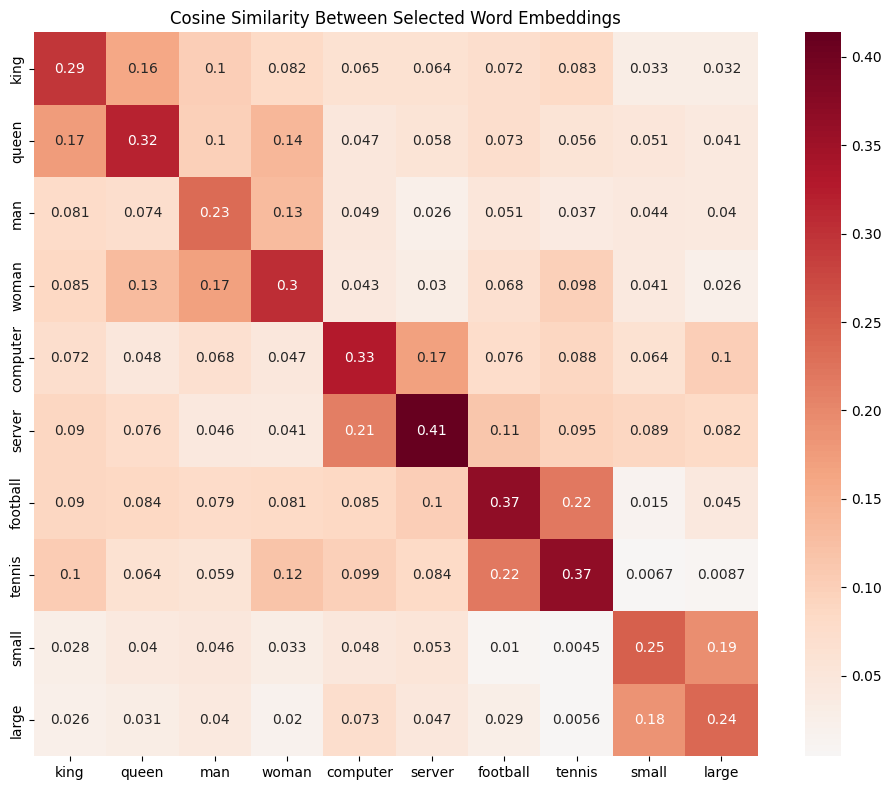

In [9]:
import seaborn as sns
from evaluate import cosine_sim
# Compare 20 hand-picked words
test_words = ["king", "queen", "man", "woman", "computer", "server", "football", "tennis", "small", "large"]
test_ids = [vocab[w] for w in test_words]
sim_matrix = cosine_sim(W[test_ids], W[test_ids])

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, xticklabels=test_words, yticklabels=test_words, 
            annot=True, cmap='RdBu_r', center=0, square=True)
plt.title("Cosine Similarity Between Selected Word Embeddings")
plt.tight_layout()
plt.show()


#### Comparison to Random

In [10]:
# Compare to random vectors (same shape)
rng = np.random.default_rng(42)
W_random = rng.uniform(-0.5/100, 0.5/100, W.shape)

print("=== king neighbors: TRAINED vs RANDOM ===")
print("Trained:")
nearest_neighbors("king", vocab, idx2word, W, top_k=5)
print("\nRandom:")
nearest_neighbors("king", vocab, idx2word, W_random, top_k=5)


=== king neighbors: TRAINED vs RANDOM ===
Trained:
  aedh            0.7621
  lulach          0.7418
  plantagenet     0.7375
  chilperic       0.7366
  pretender       0.7328

Random:
  li              0.4131
  shrieks         0.3972
  micelle         0.3603
  zahra           0.3602
  cohomology      0.3601
